In [4]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
baseline_blocks = gdf = pd.read_pickle("./data/traning_data/blocks.pickle")
baseline_blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,capacity_prison,count_prison,capacity_landfill,count_landfill,capacity_plant_nursery,count_plant_nursery,capacity_greenhouse_complex,count_greenhouse_complex,capacity_warehouse,count_warehouse
0,"POLYGON ((349424.859 6631180.891, 349424.751 6...",0.000000,0.0,0.000000,0.0,1.000000,0.0,0.000000,LandUse.TRANSPORT,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.0,0.401072,0.0,0.417018,LandUse.AGRICULTURE,0.417018,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,LandUse.RESIDENTIAL,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.0,0.000000,0.0,0.000000,LandUse.RESIDENTIAL,0.729125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.0,0.144935,0.0,0.399984,LandUse.RESIDENTIAL,0.454375,...,0.0,0.0,0.0,0.0,30.0,1.0,0.0,0.0,0.0,0.0


In [3]:
from blocksnet.analysis.indicators import calculate_density_indicators 

# 1. Если CRS географический (deg), переведём в метрический (например, Меркатор)
if baseline_blocks.crs.is_geographic:
    blocks = baseline_blocks.to_crs(epsg=3857)

# 2. Считаем площадь каждого квартала в м²
baseline_blocks['site_area'] = baseline_blocks.geometry.area

blocks_df = calculate_density_indicators(baseline_blocks[[
    'site_area',
    'footprint_area', 
    'build_floor_area',
    'living_area',
    'non_living_area'
]])
blocks_df

,site_area,footprint_area,build_floor_area,living_area,non_living_area,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,0.032316,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,inf,NaN,NaN
1,137101.088247,69.018103,69.018103,0.000000,69.018103,0.000503,0.000503,0.000000,1.000000,1985.451134,0.000000,1.000000
2,95239.084434,5853.863274,6106.759644,4197.188633,1909.571011,0.064120,0.061465,0.687302,1.043202,14.637095,0.716995,0.326207
3,125919.330984,4214.828165,4375.483259,3033.795607,1341.687653,0.034748,0.033472,0.693362,1.038117,27.815100,0.719791,0.318326
4,169860.164494,13392.846325,31242.324144,20860.965881,10381.358263,0.183930,0.078846,0.667715,2.332762,5.008184,1.557620,0.775142
...,...,...,...,...,...,...,...,...,...,...,...,...
9363,16802.384600,4360.962708,21549.418762,9911.577637,11637.841125,1.282521,0.259544,0.459946,4.941436,0.577344,2.272796,2.668640
9364,47637.956433,14963.573074,73149.192154,0.000000,73149.192154,1.535523,0.314110,0.000000,4.888484,0.446681,0.000000,4.888484
9365,64487.699525,25.673922,25.673922,0.000000,25.673922,0.000398,0.000398,0.000000,1.000000,2510.797791,0.000000,1.000000
9366,42988.399080,12973.889317,52737.331333,0.000000,52737.331333,1.226781,0.301800,0.000000,4.064882,0.569132,0.000000,4.064882


In [4]:
baseline_blocks.loc[:, blocks_df.columns] = blocks_df
baseline_blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,capacity_warehouse,count_warehouse,site_area,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,"POLYGON ((349424.859 6631180.891, 349424.751 6...",0.000000,0.0,0.000000,0.0,1.000000,0.0,0.000000,LandUse.TRANSPORT,1.000000,...,0.0,0.0,0.032316,0.000000,0.000000,NaN,NaN,inf,NaN,NaN
1,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.0,0.401072,0.0,0.417018,LandUse.AGRICULTURE,0.417018,...,0.0,0.0,137101.088247,0.000503,0.000503,0.000000,1.000000,1985.451134,0.000000,1.000000
2,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,LandUse.RESIDENTIAL,1.000000,...,0.0,0.0,95239.084434,0.064120,0.061465,0.687302,1.043202,14.637095,0.716995,0.326207
3,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.0,0.000000,0.0,0.000000,LandUse.RESIDENTIAL,0.729125,...,0.0,0.0,125919.330984,0.034748,0.033472,0.693362,1.038117,27.815100,0.719791,0.318326
4,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.0,0.144935,0.0,0.399984,LandUse.RESIDENTIAL,0.454375,...,0.0,0.0,169860.164494,0.183930,0.078846,0.667715,2.332762,5.008184,1.557620,0.775142


In [5]:
from blocksnet.analysis.morphotypes import get_strelka_morphotypes


blocks_df = get_strelka_morphotypes(baseline_blocks)
blocks_df

,l,fsi,mxi,morphotype
0,0.000000,0.000000,0.000000,NaN
1,1.000000,0.000503,0.000000,low-rise non-residential
2,1.043202,0.064120,0.687302,individual residential
3,1.038117,0.034748,0.693362,individual residential
4,2.332762,0.183930,0.667715,low-rise model
...,...,...,...,...
9363,4.941436,1.282521,0.459946,mid-rise
9364,4.888484,1.535523,0.000000,mid-rise non-residential
9365,1.000000,0.000398,0.000000,low-rise non-residential
9366,4.064882,1.226781,0.000000,mid-rise non-residential


In [6]:
baseline_blocks.loc[:, blocks_df.columns] = blocks_df
baseline_blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,count_warehouse,site_area,fsi,gsi,mxi,l,osr,share_living,share_non_living,morphotype
0,"POLYGON ((349424.859 6631180.891, 349424.751 6...",0.000000,0.0,0.000000,0.0,1.000000,0.0,0.000000,LandUse.TRANSPORT,1.000000,...,0.0,0.032316,0.000000,0.000000,0.000000,0.000000,inf,NaN,NaN,NaN
1,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.0,0.401072,0.0,0.417018,LandUse.AGRICULTURE,0.417018,...,0.0,137101.088247,0.000503,0.000503,0.000000,1.000000,1985.451134,0.000000,1.000000,low-rise non-residential
2,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,LandUse.RESIDENTIAL,1.000000,...,0.0,95239.084434,0.064120,0.061465,0.687302,1.043202,14.637095,0.716995,0.326207,individual residential
3,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.0,0.000000,0.0,0.000000,LandUse.RESIDENTIAL,0.729125,...,0.0,125919.330984,0.034748,0.033472,0.693362,1.038117,27.815100,0.719791,0.318326,individual residential
4,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.0,0.144935,0.0,0.399984,LandUse.RESIDENTIAL,0.454375,...,0.0,169860.164494,0.183930,0.078846,0.667715,2.332762,5.008184,1.557620,0.775142,low-rise model


In [7]:
from blocksnet.relations import generate_adjacency_graph

adjacency_graph = generate_adjacency_graph(baseline_blocks)


accessibility_matrix = pd.read_pickle('./data/traning_data/acc_mx.pickle')
accessibility_matrix.head()

2025-12-22 19:19:13.598 | INFO     | blocksnet.relations.adjacency.core:_generate_adjacency_nodes:9 - Generating nodes
2025-12-22 19:19:13.602 | INFO     | blocksnet.relations.adjacency.core:_generate_adjacency_edges:14 - Generating edges


2025-12-22 19:19:14.888 | SUCCESS  | blocksnet.relations.adjacency.core:generate_adjacency_graph:37 - Adjacency graph successfully generated: 9368 nodes, 27879 edges
/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,0,1,2,3,4,5,6,7,8,9,...,9358,9359,9360,9361,9362,9363,9364,9365,9366,9367
0,0.0000,58.15625,74.187500,76.937500,66.8125,80.5000,92.18750,66.56250,65.68750,106.8750,...,70.0000,72.1875,72.0000,73.3125,73.2500,74.0000,75.5000,83.1875,75.0000,73.2500
1,56.2500,0.00000,99.687500,102.375000,88.1250,76.1250,113.43750,89.43750,88.56250,96.3125,...,65.6250,67.7500,67.6875,69.0000,68.8750,69.6875,71.1875,78.8125,70.6875,68.8750
2,74.5000,96.50000,0.000000,5.347656,74.0000,118.8125,92.06250,64.43750,63.56250,134.5000,...,108.3125,110.4375,110.3750,111.6875,111.5625,112.3750,113.8125,121.5000,113.3750,111.5625
3,77.2500,99.25000,5.347656,0.000000,76.7500,121.5625,90.12500,67.18750,66.31250,137.2500,...,111.0625,113.1875,113.0625,114.3750,114.3125,115.0625,116.5625,124.2500,116.1250,114.3125
4,70.1875,90.56250,82.375000,85.125000,0.0000,110.5000,35.53125,45.15625,44.28125,89.8750,...,100.0000,102.1250,102.0000,103.3125,103.2500,104.0000,105.5000,113.1875,105.0000,103.2500


In [8]:
from blocksnet.analysis.network.accessibility import area_accessibility

area_acc_df = area_accessibility(accessibility_matrix, baseline_blocks)
baseline_blocks= baseline_blocks.join(area_acc_df)

In [9]:
cols_to_drop = [col for col in baseline_blocks.columns if col.startswith('capacity')]
baseline_blocks = baseline_blocks.drop(columns=cols_to_drop)
# cols_to_drop = [col for col in blocks.columns if col.startswith('count')]
# blocks = blocks.drop(columns='cluster')
# blocks = blocks.drop(columns=cols_to_drop)

baseline_blocks.columns

Index(['geometry', 'residential', 'business', 'recreation', 'industrial',
       'transport', 'special', 'agriculture', 'land_use', 'share',
       'footprint_area', 'build_floor_area', 'living_area', 'non_living_area',
       'population', 'count_buildings', 'count_school', 'count_kindergarten',
       'count_hospital', 'count_polyclinic', 'count_pitch',
       'count_swimming_pool', 'count_theatre', 'count_museum', 'count_cinema',
       'count_mall', 'count_convenience', 'count_supermarket',
       'count_cemetery', 'count_religion', 'count_market', 'count_university',
       'count_playground', 'count_pharmacy', 'count_fuel', 'count_beach',
       'count_train_building', 'count_bank', 'count_lawyer', 'count_cafe',
       'count_subway_entrance', 'count_multifunctional_center',
       'count_hairdresser', 'count_restaurant', 'count_bar', 'count_park',
       'count_government', 'count_recruitment', 'count_hotel', 'count_zoo',
       'count_circus', 'count_post', 'count_police', 'cou

In [10]:
# cols = [
#     'residential','business','recreation','industrial','transport','special',
#     'agriculture','land_use','share','footprint_area','build_floor_area',
#     'living_area','non_living_area','population','site_area','fsi','gsi',
#     'mxi','l','morphotype','area_accessibility', 'geometry'
# ]
# baseline_blocks = baseline_blocks[cols]
# baseline_blocks.head()

In [11]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator
model = CatBoostRegressor()

model.load_model('./data/models/land_value_catboost_22_12.cbm')

estimator = LandPriceEstimator(
    model=model,
    blocks=baseline_blocks, #or blocks_198
    use_service_features=True, 
)
blocks_pred = estimator.predict()
blocks_pred.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,fsi,gsi,mxi,l,osr,share_living,share_non_living,morphotype,area_accessibility,land_value
0,"POLYGON ((349424.859 6631180.891, 349424.751 6...",0.000000,0.0,0.000000,0.0,1.000000,0.0,0.000000,LandUse.TRANSPORT,1.000000,...,0.000000,0.000000,0.000000,0.000000,inf,NaN,NaN,NaN,114.184718,3.104150e+01
1,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.0,0.401072,0.0,0.417018,LandUse.AGRICULTURE,0.417018,...,0.000503,0.000503,0.000000,1.000000,1985.451134,0.000000,1.000000,low-rise non-residential,113.847998,1.302609e+08
2,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,LandUse.RESIDENTIAL,1.000000,...,0.064120,0.061465,0.687302,1.043202,14.637095,0.716995,0.326207,individual residential,145.884534,1.866221e+08
3,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.0,0.000000,0.0,0.000000,LandUse.RESIDENTIAL,0.729125,...,0.034748,0.033472,0.693362,1.038117,27.815100,0.719791,0.318326,individual residential,148.543184,1.921933e+08
4,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.0,0.144935,0.0,0.399984,LandUse.RESIDENTIAL,0.454375,...,0.183930,0.078846,0.667715,2.332762,5.008184,1.557620,0.775142,low-rise model,132.691062,3.561835e+08


count    9.180000e+03
mean     3.817605e+05
std      4.078004e+05
min      0.000000e+00
25%      1.098691e+05
50%      2.473773e+05
75%      4.838536e+05
max      2.344358e+06
Name: land_value_per_100m2, dtype: float64


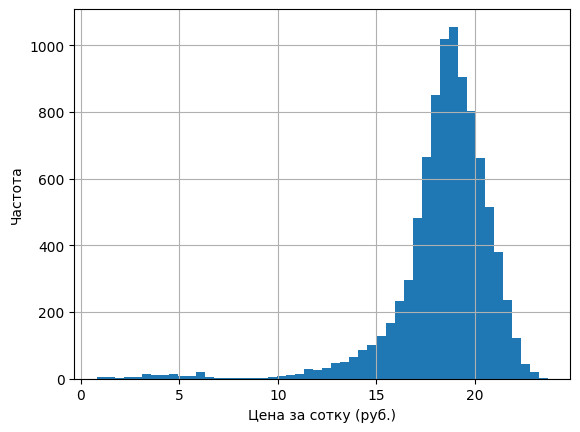

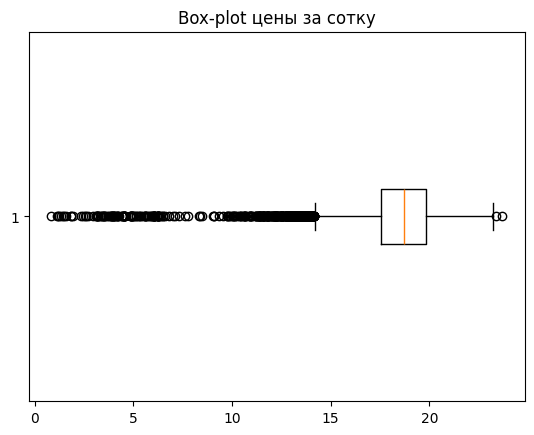

In [12]:
import numpy as np
import matplotlib.pyplot as plt
# 1) Цена за сотку (100 м²)
blocks_pred["land_value_per_100m2"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

blocks_pred['log_total_price'] = np.log1p(blocks_pred['land_value'])
# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_100m2"].quantile(0.98)
blocks_clean = blocks_pred[blocks_pred["land_value_per_100m2"] <= p99].copy()

# p99 = blocks_clean["land_value"].quantile(0.98)
# blocks_clean = blocks_clean[blocks_clean["land_value"] <= p99].copy()

print(blocks_clean["land_value_per_100m2"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["log_total_price"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
# plt.title("Распределение цены за сотку")
plt.show()

# 5) Box-plot после очистки
plt.figure()
plt.boxplot(blocks_clean["log_total_price"].dropna(), vert=False)
# plt.xlabel("Цена за сотку (руб.)")
plt.title("Box-plot цены за сотку")
plt.show()


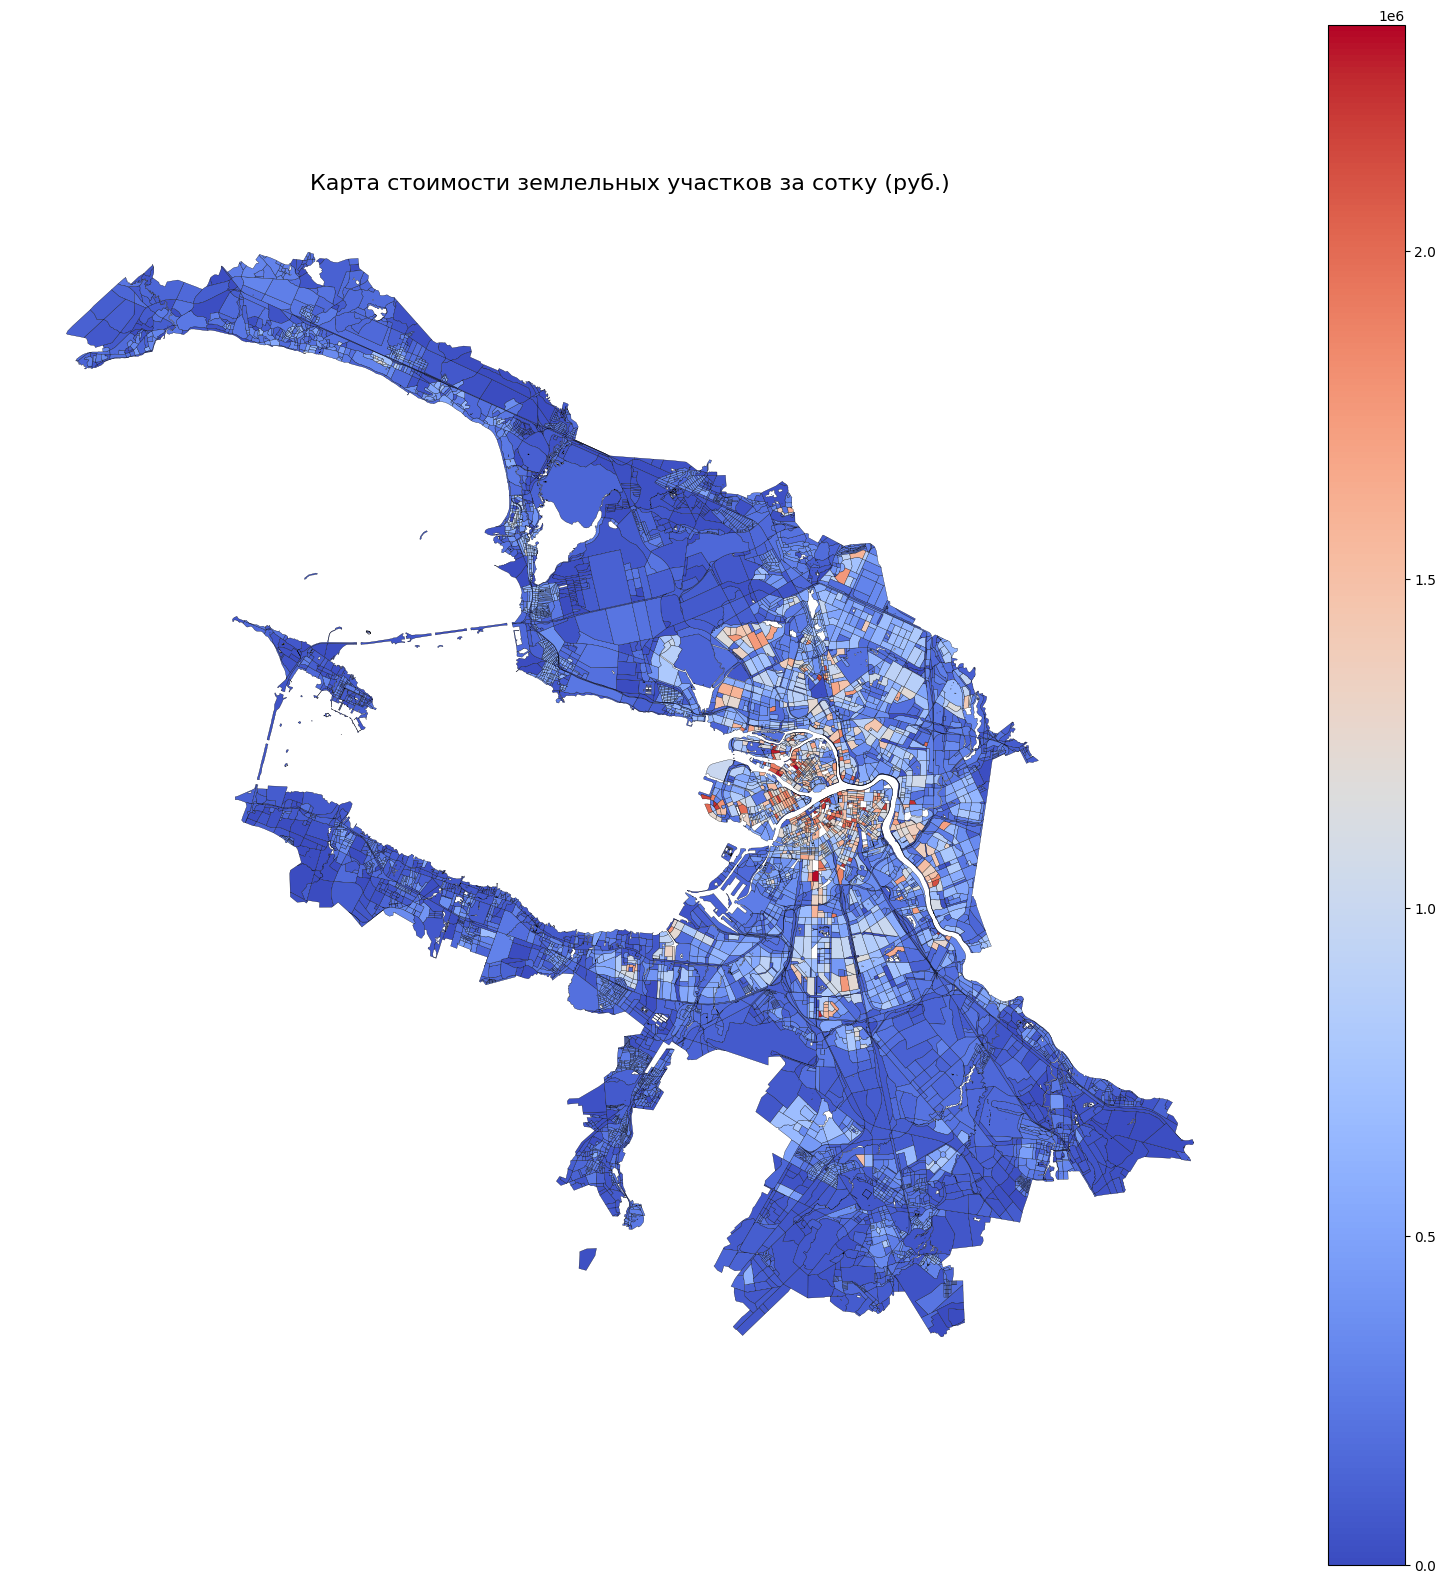

In [13]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value_per_100m2',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости землельных участков за сотку (руб.)', fontsize=16)

plt.show()

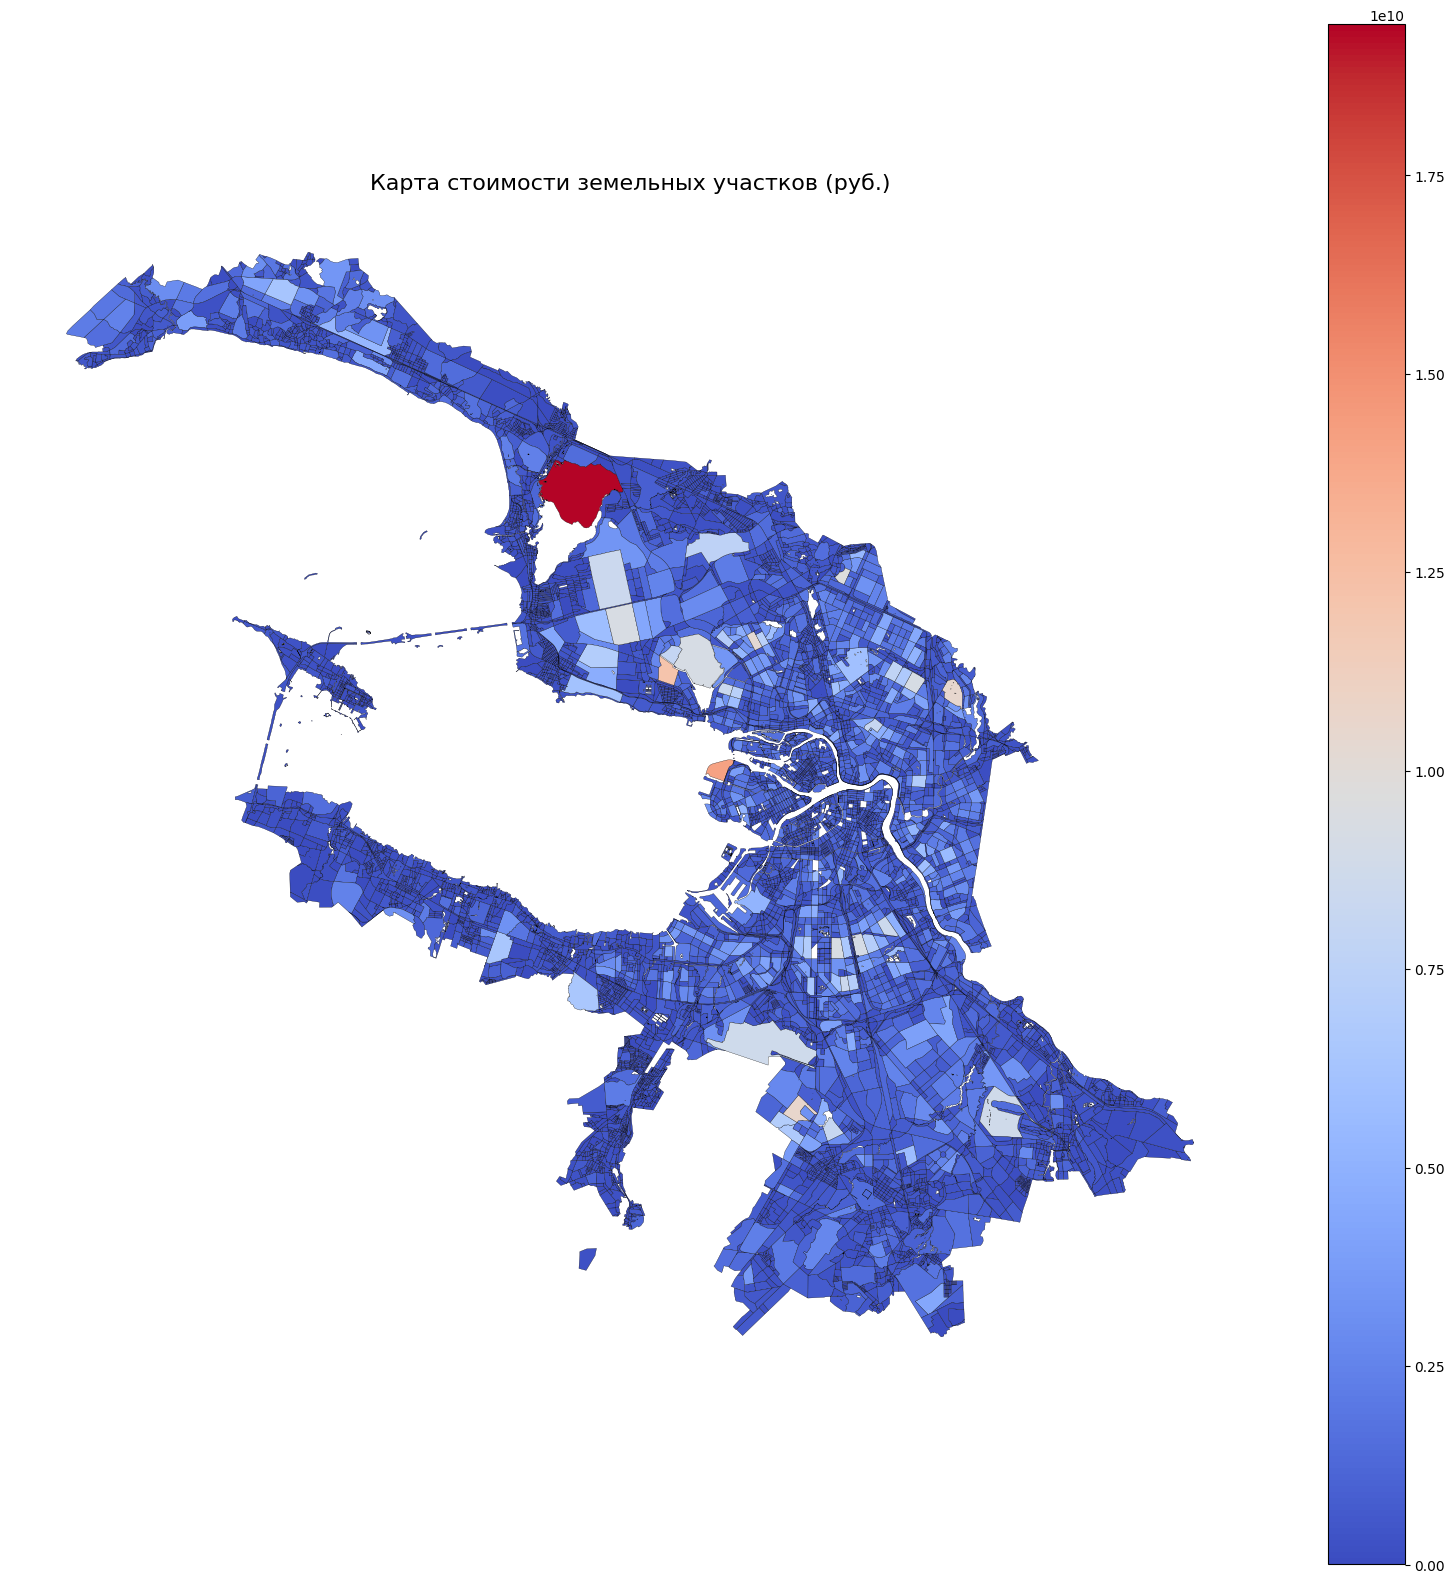

In [14]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

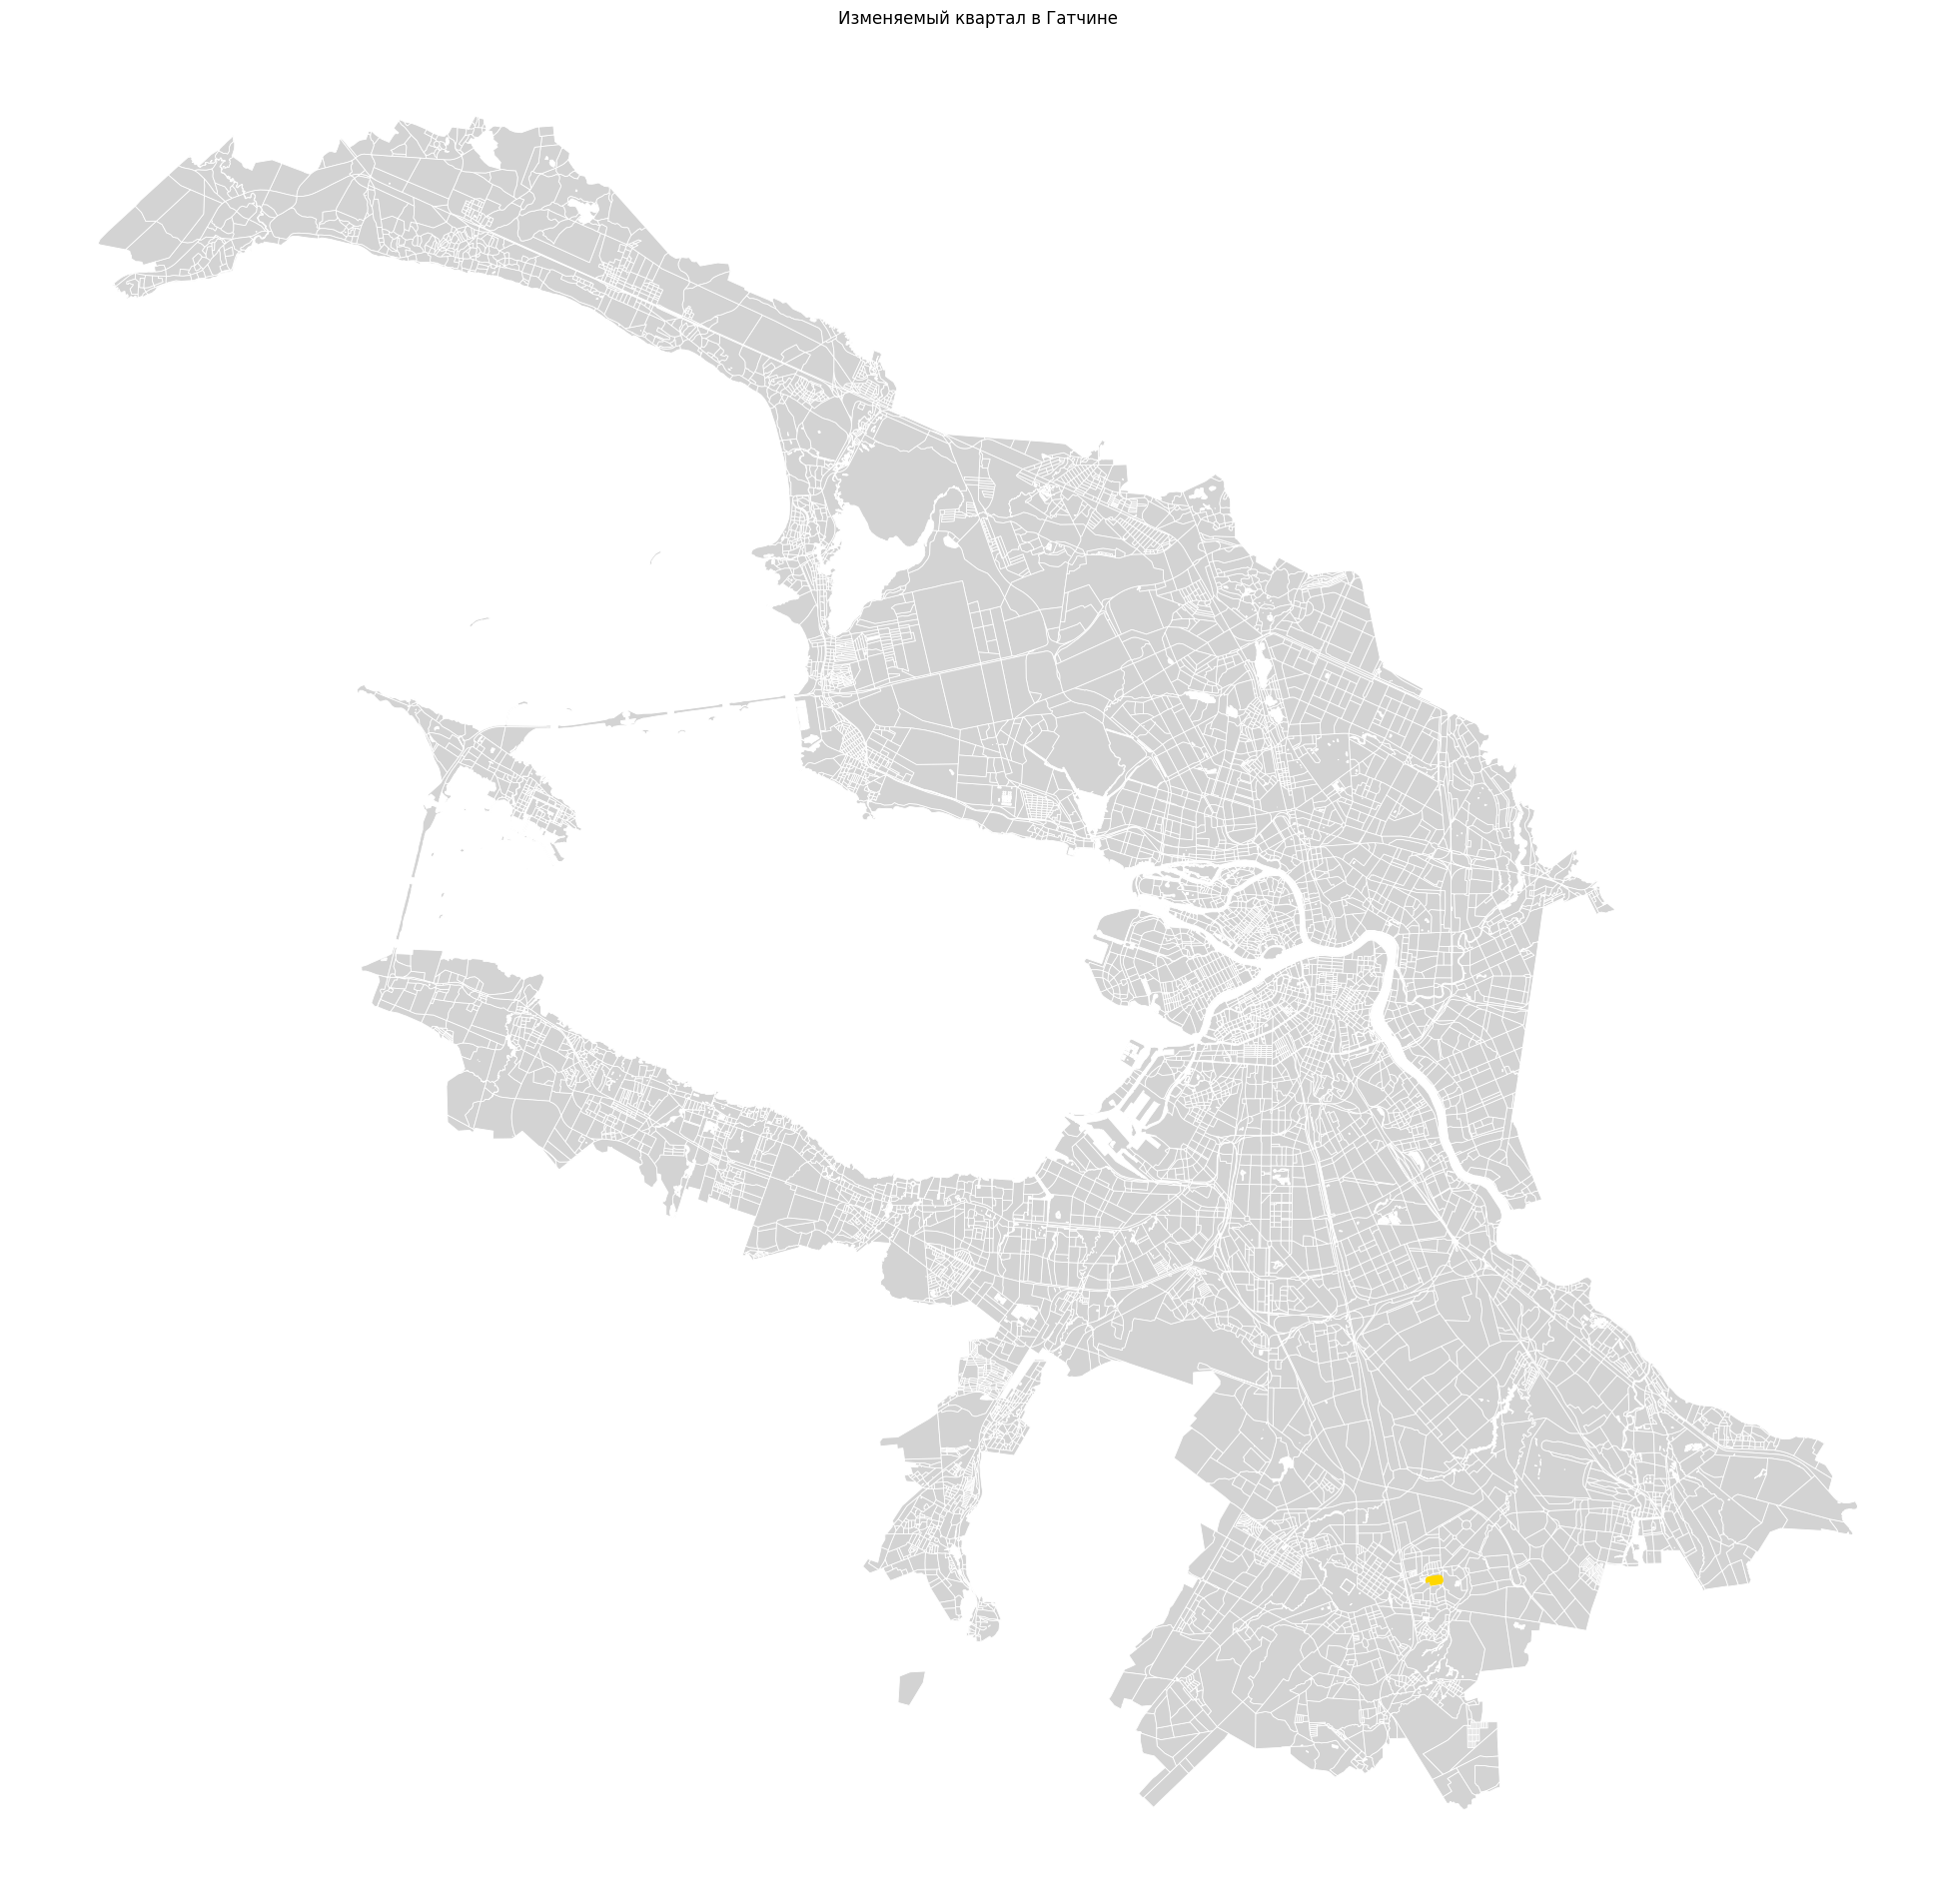

In [21]:
import matplotlib.pyplot as plt
baseline_blocks["id"] = baseline_blocks.index

target_idx = 723


fig, ax = plt.subplots(figsize=(25, 35))
baseline_blocks.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)  # фон
baseline_blocks.loc[baseline_blocks["id"]==target_idx].plot(
    ax=ax, color="none", edgecolor="gold", linewidth=5.5
)
ax.set_title("Изменяемый квартал в Гатчине")
ax.axis("off")
plt.show()

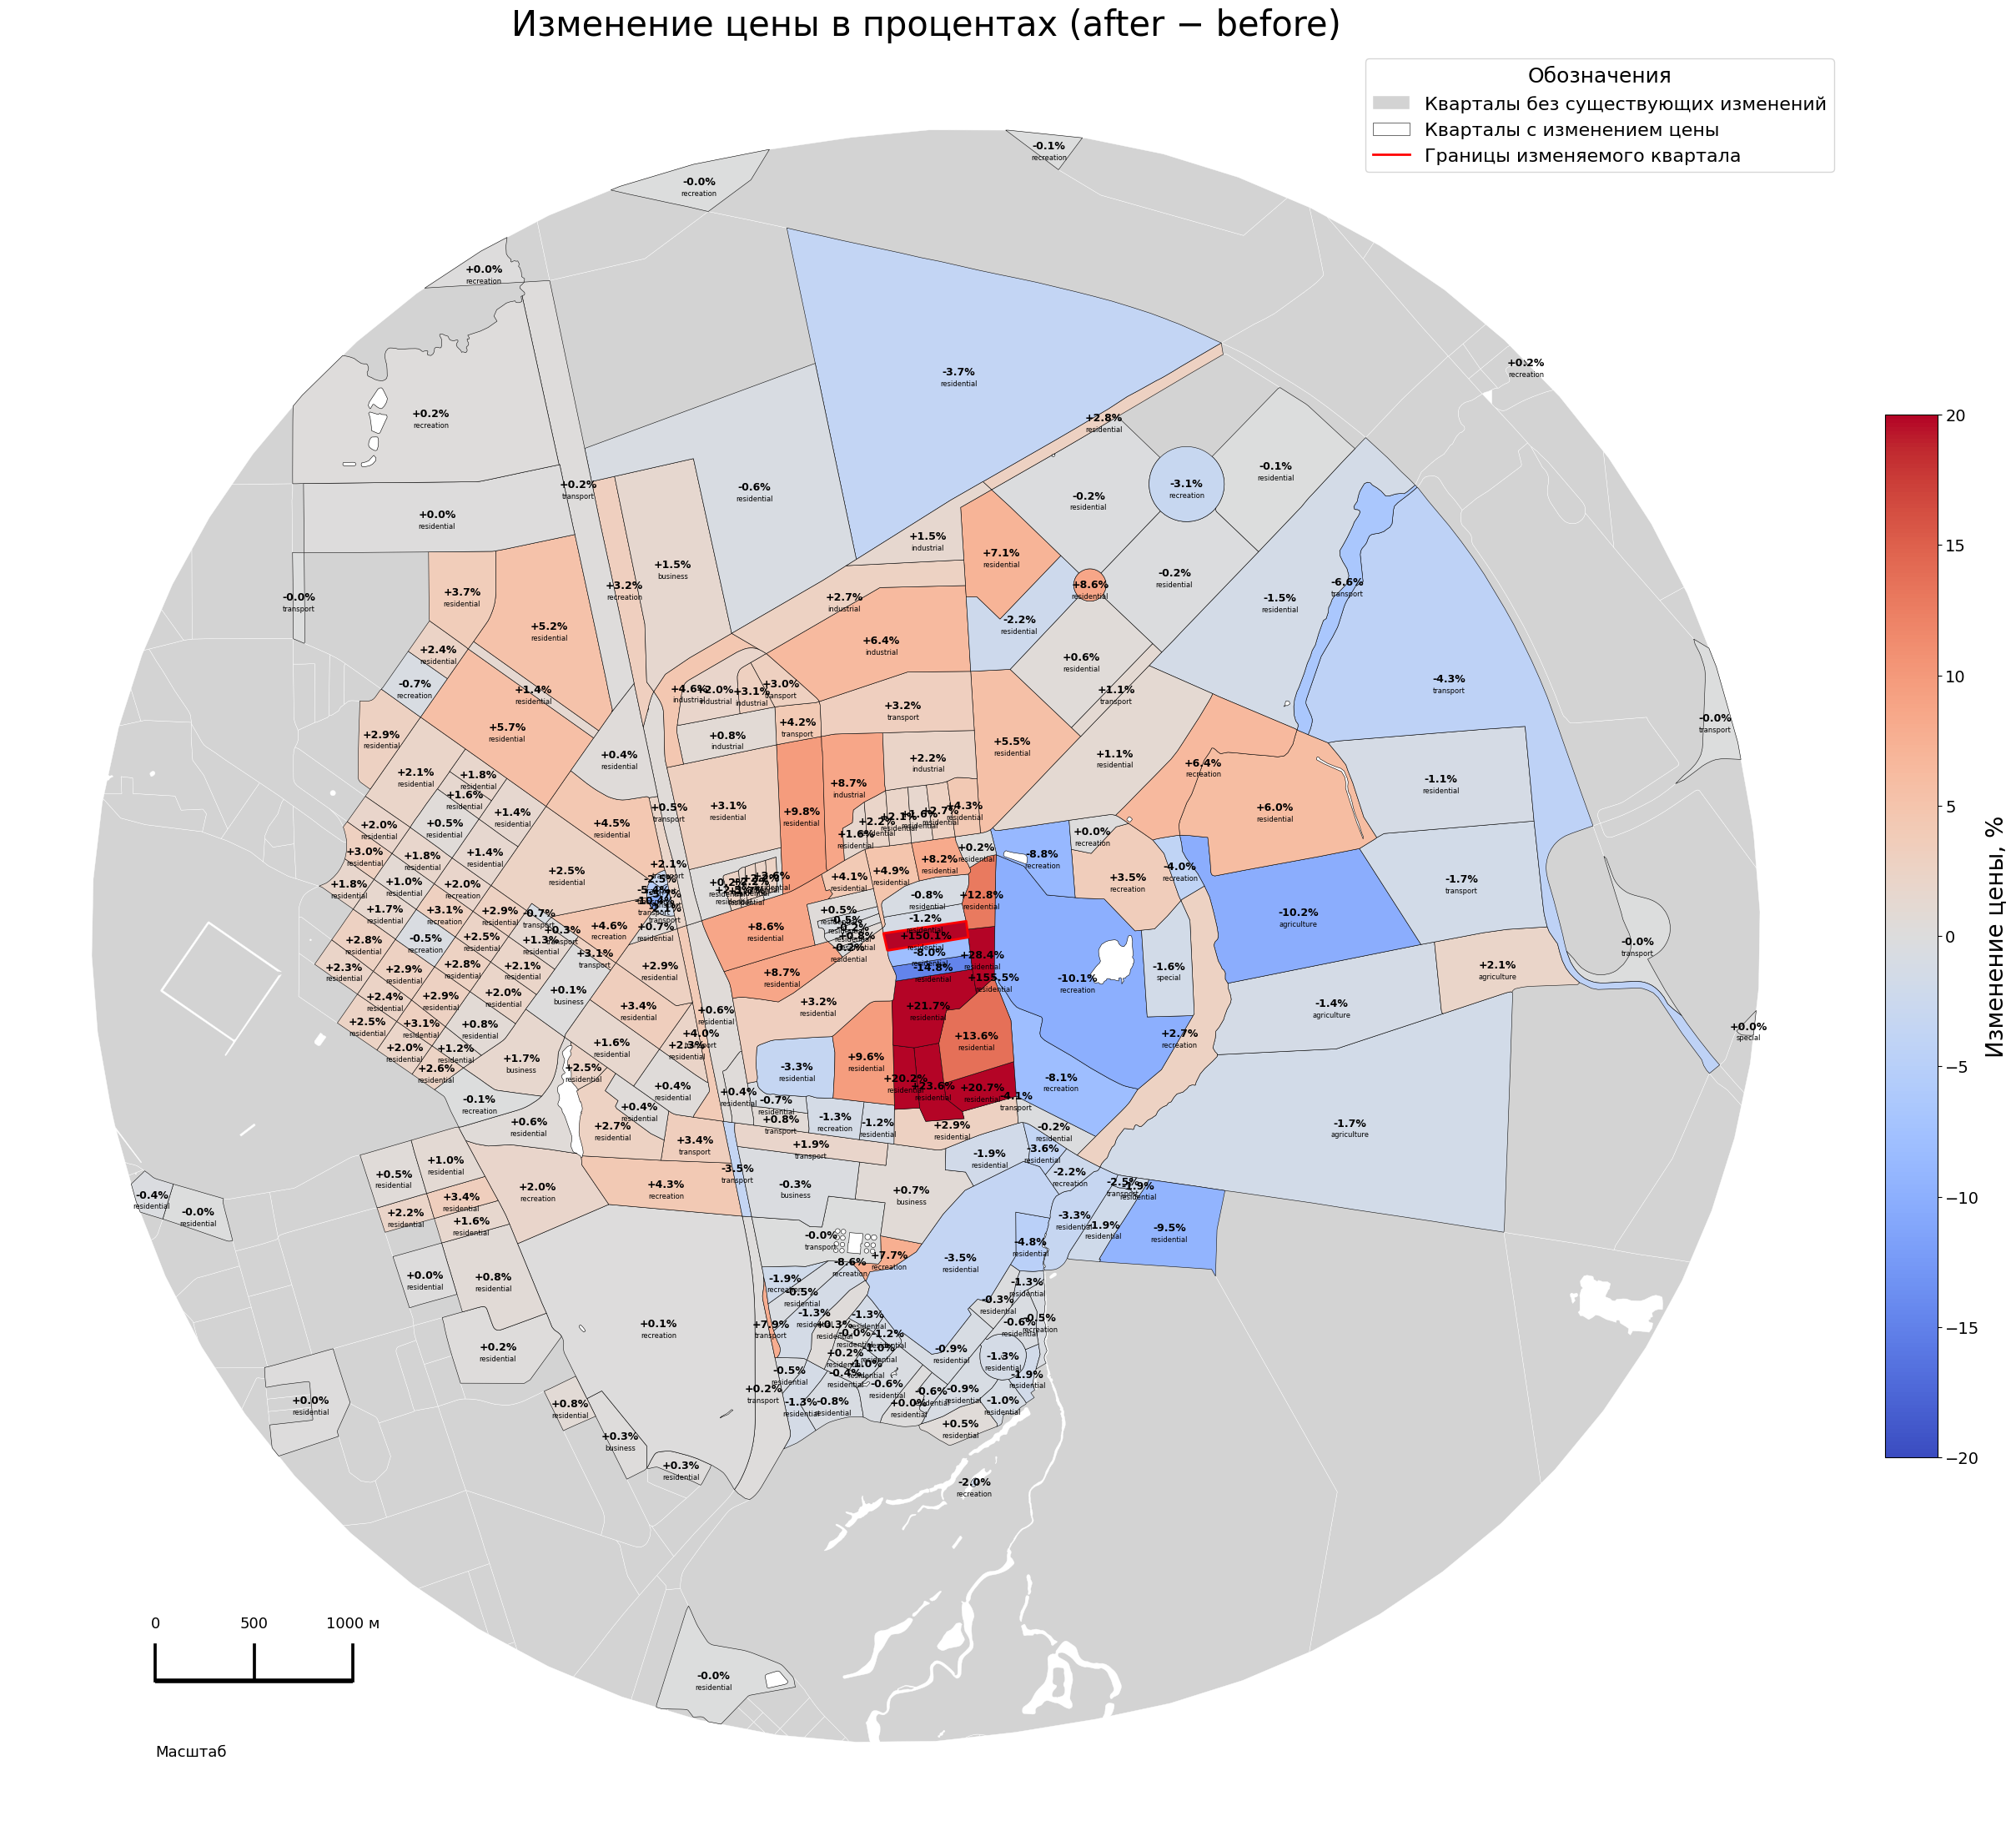


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
723 | residential | 77 829 306 ₽ → 194 645 967 ₽ | +116 816 661 ₽ | +150.1%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
9309 | agriculture | 1 123 314 444 ₽ → 1 104 395 410 ₽ | -18 919 033 ₽ | -1.7%
9308 | agriculture | 346 093 249 ₽ → 341 393 544 ₽ | -4 699 704 ₽ | -1.4%
1144 | agriculture | 169 301 841 ₽ → 172 804 680 ₽ | +3 502 840 ₽ | +2.1%
6573 | transport | 93 157 022 ₽ → 93 148 743 ₽ | -8 279 ₽ | -0.0%
665 | agriculture | 350 485 274 ₽ → 314 857 447 ₽ | -35 627 827 ₽ | -10.2%
1297 | special | 60 447 470 ₽ → 60 472 507 ₽ | +25 037 ₽ | +0.0%
715 | transport | 470 612 505 ₽ → 462 784 049 ₽ | -7 828 456 ₽ | -1.7%
716 | residential | 508 523 172 ₽ → 539 009 721 ₽ | +30 486 549 ₽ | +6.0%
717 | residential | 440 018 675 ₽ → 435 058 400 ₽ | -4 960 275 ₽ | -1.1%
6

In [22]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
    transfer_baseline_prices,
)

blocks_before = baseline_blocks.copy()

changes = {
    # Структура использования территории
    "land_use": "LandUse.RESIDENTIAL",
    "residential": 0.8,
    "business": 0.2,
    "recreation": 0.0,
    "industrial": 0.0,
    "transport": 0.0,
    "special": 0.0,
    "agriculture": 0.0,
    "share": 1.0,

    "footprint_area": 48170.0451624,    # ≈ 60% от site_area
    "build_floor_area": 481700.451624,  # FSI ≈ 6.0
    "living_area": 337190.3161368,      # ≈ 70% 
    "non_living_area": 144510.1354872,  # ≈ 30% 
    "population": 5537,                # 


    "fsi": 6.0,                         # build_floor_area / site_area
    "gsi": 0.60,                        # footprint_area / site_area
    "l": 10.0,                          # build_floor_area / footprint_area (этажность)
                    # build_floor_area / footprint_area (этажность)

    # Морфотип – высотный дом
    "morphotype": "high-rise residential",
    }


modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

# 1) Предсказание стоимости до/после
before_estimator = LandPriceEstimator(model=model, blocks=blocks_before, use_service_features=True,)
after_estimator = LandPriceEstimator(model=model, blocks=blocks_after, use_service_features=True,)

blocks_before_pred = before_estimator.predict()
blocks_before_pred["land_value_per_100m2"] = blocks_before_pred["land_value"] / blocks_before_pred["site_area"] * 100

blocks_after_pred = after_estimator.predict()
blocks_after_pred["land_value_per_100m2"] = blocks_after_pred["land_value"] / blocks_after_pred["site_area"] * 100

blocks_full_value = transfer_baseline_prices(
    after_blocks=blocks_after_pred,
    before_blocks=blocks_before_pred,
    scenario_mode=False,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)
blocks_full_value = blocks_full_value.fillna(0)

# 3) Только визуализация и статистика по процентным изменениям
scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_idx,          
    target_id_column="id",   # если колонка называется иначе — укажи здесь
    figsize=(25, 35),
)